# UNet Training for Chess Board Segmentation

**Goal:** Train a U-Net model to segment chess boards from images.

**Pipeline:**
1. Load training data from `Board_coordinates/{train,validation}/` (images + JSON polygon masks)
2. Initialize U-Net with ResNet34 encoder
3. Train with DiceLoss and Adam optimizer
4. Save best model to `best_unet_model.pth`

**Note:** This notebook contains ONLY training code. For inference/demo, see `03b_unet_inference_demo.ipynb`.

In [2]:
# Install required packages if not available
import subprocess
import sys

def install_package(package):
    """Install a package if not already installed."""
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

# Install PyTorch and segmentation-models-pytorch if needed
try:
    import torch
    import segmentation_models_pytorch as smp
    print("✓ PyTorch and segmentation-models-pytorch are available")
except ImportError:
    print("Installing required packages...")
    install_package("torch")
    install_package("torchvision")
    install_package("segmentation-models-pytorch")
    import torch
    import segmentation_models_pytorch as smp
    print("✓ Installation complete")

# Standard imports
import os
import json
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up paths (relative paths from workspace root)
possible_roots = [
    Path.cwd().parent,  # If running from notebooks/ directory
    Path.cwd(),         # If running from workspace root
]

PROJECT_ROOT = None
for root in possible_roots:
    test_path = root / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Board_coordinates"
    if test_path.exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()

BASE_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "Chess Pieces Detection Image Dataset" / "Board_coordinates"

TRAIN_IMG_DIR = BASE_DATA_DIR / "train/images"
TRAIN_JSON = BASE_DATA_DIR / "train/labels/train_coordinates.json"

VAL_IMG_DIR = BASE_DATA_DIR / "validation/images"
VAL_JSON = BASE_DATA_DIR / "validation/labels/val_coordinates.json"

# Hyperparameters
IMAGE_SIZE = 320
BATCH_SIZE = 8
EPOCHS = 20
LEARNING_RATE = 1e-4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Project root: {PROJECT_ROOT}")
print(f"Training images: {TRAIN_IMG_DIR}")
print(f"Training JSON: {TRAIN_JSON}")
print(f"Validation images: {VAL_IMG_DIR}")
print(f"Validation JSON: {VAL_JSON}")
print(f"Device: {DEVICE}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")

✓ PyTorch and segmentation-models-pytorch are available
Project root: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision
Training images: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/raw/Chess Pieces Detection Image Dataset/Board_coordinates/train/images
Training JSON: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/raw/Chess Pieces Detection Image Dataset/Board_coordinates/train/labels/train_coordinates.json
Validation images: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/data/raw/Chess Pieces Detection Image Dataset/Board_coordinates/validation/images
Validation JSON: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu

## Dataset Class

In [3]:
class ChessBoardDataset(Dataset):
    """Dataset for loading chess board images and polygon masks from JSON."""

    def __init__(self, json_path, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        # Load the JSON data
        if not os.path.exists(json_path):
            raise FileNotFoundError(f"JSON not found at {json_path}")

        with open(json_path, 'r') as f:
            self.data = json.load(f)

        # We use the keys from the JSON to drive the loading
        self.keys = list(self.data.keys())

        # Preprocessing for the ResNet backbone
        self.preprocessing_fn = smp.encoders.get_preprocessing_fn('resnet34', 'imagenet')

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        # 1. Get info from JSON
        key = self.keys[idx]
        entry = self.data[key]
        filename = entry['filename']
        img_path = os.path.join(self.img_dir, filename)

        # 2. Load Image
        image = cv2.imread(img_path)
        if image is None:
            # Fallback for missing images to avoid crashing
            print(f"Warning: Image not found {filename}")
            return self.__getitem__((idx + 1) % len(self))

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = image.shape[:2]

        # 3. Generate Binary Mask from JSON Polygon
        mask = np.zeros((orig_h, orig_w), dtype=np.uint8)
        try:
            for region_id, region_data in entry['regions'].items():
                attr = region_data['shape_attributes']
                if attr['name'] == 'polygon':
                    xs = attr['all_points_x']
                    ys = attr['all_points_y']
                    points = np.array(list(zip(xs, ys)), dtype=np.int32)
                    cv2.fillPoly(mask, [points], 1)  # 1 = Board, 0 = Background
        except KeyError:
            pass

        # 4. Resize (Essential for U-Net)
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
        mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)

        # 5. Preprocess (Normalize)
        image = self.preprocessing_fn(image)

        # 6. Convert to Tensor (Channels First: C, H, W)
        image = image.transpose(2, 0, 1).astype('float32')
        mask = np.expand_dims(mask, 0).astype('float32')

        return torch.from_numpy(image), torch.from_numpy(mask)

print("✓ Dataset class defined")

✓ Dataset class defined


## Training Function

In [ ]:
def train_unet():
    """Train UNet model and save best checkpoint."""
    print(f"Using device: {DEVICE}")

    # 1. Setup Datasets
    print("Loading datasets...")
    train_dataset = ChessBoardDataset(TRAIN_JSON, TRAIN_IMG_DIR)

    # Only load val if files exist, otherwise skip
    if os.path.exists(VAL_JSON):
        val_dataset = ChessBoardDataset(VAL_JSON, VAL_IMG_DIR)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
        print(f"Validation set loaded: {len(val_dataset)} images")
    else:
        val_loader = None
        print("Validation set not found, skipping validation.")

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    print(f"Training set loaded: {len(train_dataset)} images")

    # 2. Initialize Model
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        activation=None
    ).to(DEVICE)

    # 3. Optimizer & Loss
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = smp.losses.DiceLoss(mode='binary', from_logits=True)

    # 4. Training Loop
    best_loss = float('inf')
    model_output_path = PROJECT_ROOT / "notebooks" / "best_unet_model.pth"

    print("\nStarting Training...")
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0

        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation Step
        val_log = ""
        if val_loader:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for images, masks in val_loader:
                    images, masks = images.to(DEVICE), masks.to(DEVICE)
                    outputs = model(images)
                    loss = criterion(outputs, masks)
                    val_loss += loss.item()

            avg_val_loss = val_loss / len(val_loader)
            val_log = f"| Val Loss: {avg_val_loss:.4f}"

            # Save best model
            if avg_val_loss < best_loss:
                best_loss = avg_val_loss
                torch.save(model.state_dict(), str(model_output_path))
                val_log += " [Saved Best]"
        else:
            # If no validation, just save last
            model_output_path_last = PROJECT_ROOT / "notebooks" / "latest_unet_model.pth"
            torch.save(model.state_dict(), str(model_output_path_last))

        print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {avg_train_loss:.4f} {val_log}")

    print(f"\nTraining Complete.")
    print(f"Best model saved to: {model_output_path}")
    return model

print("✓ Training function defined")

✓ Training function defined


## Run Training

In [ ]:
if TRAIN_JSON.exists():
    model = train_unet()
else:
    print(f"Error: Could not find training JSON at {TRAIN_JSON}")

Using device: cpu
Loading datasets...


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

Validation set loaded: 42 images
Training set loaded: 129 images


model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]


Starting Training...
Epoch [1/20] Train Loss: 0.2614 | Val Loss: 0.2088 [Saved Best]
Epoch [2/20] Train Loss: 0.1493 | Val Loss: 0.1092 [Saved Best]
Epoch [3/20] Train Loss: 0.1034 | Val Loss: 0.0812 [Saved Best]
Epoch [4/20] Train Loss: 0.0825 | Val Loss: 0.0693 [Saved Best]
Epoch [5/20] Train Loss: 0.0698 | Val Loss: 0.0615 [Saved Best]
Epoch [6/20] Train Loss: 0.0598 | Val Loss: 0.0557 [Saved Best]
Epoch [7/20] Train Loss: 0.0535 | Val Loss: 0.0500 [Saved Best]
Epoch [8/20] Train Loss: 0.0477 | Val Loss: 0.0452 [Saved Best]
Epoch [9/20] Train Loss: 0.0434 | Val Loss: 0.0424 [Saved Best]
Epoch [10/20] Train Loss: 0.0400 | Val Loss: 0.0388 [Saved Best]
Epoch [11/20] Train Loss: 0.0364 | Val Loss: 0.0355 [Saved Best]
Epoch [12/20] Train Loss: 0.0337 | Val Loss: 0.0326 [Saved Best]
Epoch [13/20] Train Loss: 0.0313 | Val Loss: 0.0304 [Saved Best]
Epoch [14/20] Train Loss: 0.0296 | Val Loss: 0.0288 [Saved Best]
Epoch [15/20] Train Loss: 0.0275 | Val Loss: 0.0269 [Saved Best]
Epoch [16/20

# Evaluation / Test Metrics

This section evaluates the trained UNet model on the test split.

Loading model for test evaluation...
Processing 43 test images...
  Processed 10/43 images...
  Processed 20/43 images...
  Processed 30/43 images...
  Processed 40/43 images...

Saved test metrics to: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/outputs/unet_test_metrics.csv

UNet Test Summary:
  Total images: 43
  Successful: 43 (100.0%)
  Average IoU: 0.9848
  Average Dice: 0.9923
  Average Runtime: 101.58 ms


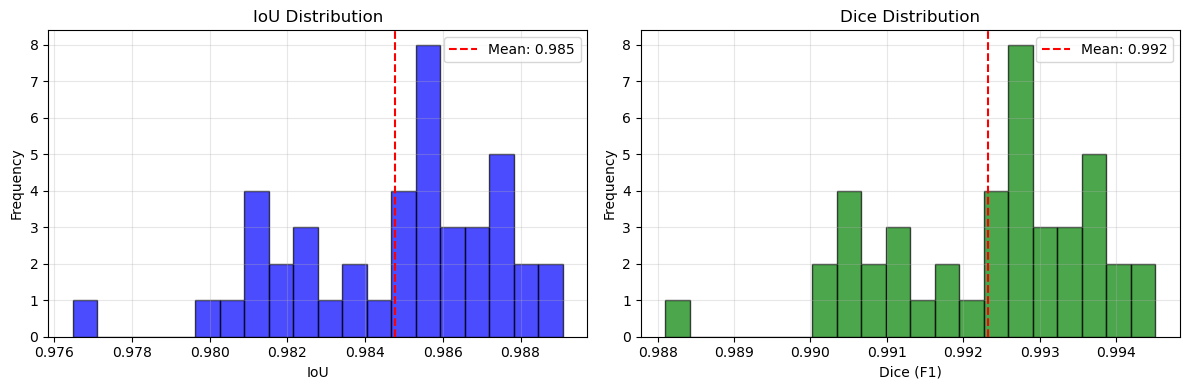

Saved figure to: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/outputs/figures/unet_iou_dice_distribution.png

Evaluation complete. Results saved to: /Users/ibrahimcbc/Library/CloudStorage/GoogleDrive-icebecioglu21@ku.edu.tr/My Drive/COMP411/assignments/COMP-411_Project/chessvision/outputs


In [4]:
# ==========================================
# UNET TEST EVALUATION
# ==========================================
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Setup paths
TEST_IMG_DIR = BASE_DATA_DIR / "test/images"
TEST_JSON = BASE_DATA_DIR / "test/labels/test_coordinates.json"
MODEL_PATH = PROJECT_ROOT / "notebooks" / "best_unet_model.pth"

# Create outputs directory
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

if not MODEL_PATH.exists():
    print(f"ERROR: Model not found at {MODEL_PATH}")
    print("Please train the model first or check the model path.")
elif not TEST_JSON.exists():
    print(f"ERROR: Test JSON not found at {TEST_JSON}")
    print("Skipping test evaluation.")
else:
    print("Loading model for test evaluation...")
    model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1, activation=None).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    
    # Helper functions
    def order_points(pts):
        rect = np.zeros((4, 2), dtype="float32")
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]; rect[2] = pts[np.argmax(s)]
        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)]; rect[3] = pts[np.argmax(diff)]
        return rect
    
    def warp_chessboard(image, mask, margin=0.0):
        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours: return None, None, None
        c = max(contours, key=cv2.contourArea)
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) != 4:
            rect = cv2.minAreaRect(c)
            box = cv2.boxPoints(rect)
            approx = np.int0(box)
        pts = approx.reshape(4, 2).astype(np.float32)
        rect = order_points(pts)
        if margin > 0:
            center = np.mean(rect, axis=0)
            rect = rect + (center - rect) * margin
        OUTPUT_SIZE = 640
        dst = np.array([[0, 0], [OUTPUT_SIZE-1, 0], [OUTPUT_SIZE-1, OUTPUT_SIZE-1], [0, OUTPUT_SIZE-1]], dtype="float32")
        M = cv2.getPerspectiveTransform(rect, dst)
        warped = cv2.warpPerspective(image, M, (OUTPUT_SIZE, OUTPUT_SIZE))
        return warped, rect, M
    
    # Load test data
    with open(TEST_JSON, 'r') as f:
        test_data = json.load(f)
    
    results = []
    prep_fn = smp.encoders.get_preprocessing_fn('resnet34', 'imagenet')
    BOARD_MARGIN = 0.02
    
    print(f"Processing {len(test_data)} test images...")
    
    for idx, (key, entry) in enumerate(test_data.items()):
        filename = entry['filename']
        img_path = TEST_IMG_DIR / filename
        
        if not img_path.exists():
            continue
        
        start_time = time.time()
        result = {
            'image_name': filename,
            'iou': None,
            'dice': None,
            'success_flag': False,
            'runtime_ms': 0,
            'error_reason': None
        }
        
        try:
            img = cv2.imread(str(img_path))
            if img is None:
                result['error_reason'] = 'Could not read image'
                result['runtime_ms'] = (time.time() - start_time) * 1000
                results.append(result)
                continue
            
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            orig_h, orig_w = img.shape[:2]
            
            # Generate ground truth mask
            gt_mask = np.zeros((orig_h, orig_w), dtype=np.uint8)
            for region_id, region_data in entry.get('regions', {}).items():
                attr = region_data.get('shape_attributes', {})
                if attr.get('name') == 'polygon':
                    xs = attr.get('all_points_x', [])
                    ys = attr.get('all_points_y', [])
                    if xs and ys:
                        points = np.array(list(zip(xs, ys)), dtype=np.int32)
                        cv2.fillPoly(gt_mask, [points], 1)
            
            # UNet inference
            resized = cv2.resize(img_rgb, (IMAGE_SIZE, IMAGE_SIZE))
            tensor = torch.from_numpy(prep_fn(resized).transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)
            
            with torch.no_grad():
                pred_logits = model(tensor)
                pred_mask = (torch.sigmoid(pred_logits) > 0.5).float().cpu().numpy()[0][0]
            
            pred_mask_full = cv2.resize(pred_mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
            pred_mask_binary = (pred_mask_full > 0.5).astype(np.uint8)
            
            # Try to warp
            warped, corners, M = warp_chessboard(img_rgb, pred_mask_binary, margin=BOARD_MARGIN)
            
            if warped is None:
                result['error_reason'] = 'Board corners not found'
                result['runtime_ms'] = (time.time() - start_time) * 1000
                results.append(result)
                continue
            
            # Compute metrics
            gt_flat = gt_mask.flatten()
            pred_flat = pred_mask_binary.flatten()
            
            intersection = np.logical_and(gt_flat, pred_flat).sum()
            union = np.logical_or(gt_flat, pred_flat).sum()
            iou = intersection / union if union > 0 else 0.0
            dice = (2.0 * intersection) / (gt_flat.sum() + pred_flat.sum()) if (gt_flat.sum() + pred_flat.sum()) > 0 else 0.0
            
            result['iou'] = float(iou)
            result['dice'] = float(dice)
            result['success_flag'] = True
            result['runtime_ms'] = (time.time() - start_time) * 1000
            
        except Exception as e:
            result['error_reason'] = str(e)
            result['runtime_ms'] = (time.time() - start_time) * 1000
        
        results.append(result)
        
        if (idx + 1) % 10 == 0:
            print(f"  Processed {idx + 1}/{len(test_data)} images...")
    
    # Save results
    df = pd.DataFrame(results)
    csv_path = OUTPUTS_DIR / "unet_test_metrics.csv"
    df.to_csv(csv_path, index=False)
    print(f"\nSaved test metrics to: {csv_path}")
    
    # Summary
    successful = df[df['success_flag'] == True]
    if len(successful) > 0:
        avg_iou = successful['iou'].mean()
        avg_dice = successful['dice'].mean()
        avg_runtime = successful['runtime_ms'].mean()
        success_rate = len(successful) / len(df) * 100
        
        print(f"\nUNet Test Summary:")
        print(f"  Total images: {len(df)}")
        print(f"  Successful: {len(successful)} ({success_rate:.1f}%)")
        print(f"  Average IoU: {avg_iou:.4f}")
        print(f"  Average Dice: {avg_dice:.4f}")
        print(f"  Average Runtime: {avg_runtime:.2f} ms")
        
        # Failure analysis
        failures = df[df['success_flag'] == False]
        if len(failures) > 0:
            print(f"\nFailure Analysis:")
            error_counts = failures['error_reason'].value_counts()
            for error, count in error_counts.items():
                print(f"  {error}: {count} ({count/len(failures)*100:.1f}%)")
        
        # Histogram
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].hist(successful['iou'], bins=20, alpha=0.7, color='blue', edgecolor='black')
        axes[0].axvline(avg_iou, color='red', linestyle='--', label=f'Mean: {avg_iou:.3f}')
        axes[0].set_xlabel('IoU')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('IoU Distribution')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        axes[1].hist(successful['dice'], bins=20, alpha=0.7, color='green', edgecolor='black')
        axes[1].axvline(avg_dice, color='red', linestyle='--', label=f'Mean: {avg_dice:.3f}')
        axes[1].set_xlabel('Dice (F1)')
        axes[1].set_ylabel('Frequency')
        axes[1].set_title('Dice Distribution')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
        
        plt.tight_layout()
        fig_path = FIGURES_DIR / "unet_iou_dice_distribution.png"
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved figure to: {fig_path}")
    else:
        print("No successful predictions to analyze.")
    
    print(f"\nEvaluation complete. Results saved to: {OUTPUTS_DIR}")